In [1]:
import pandas as pd
#from openai import OpenAI
import torch
import numpy as np
import os
import matplotlib.pyplot as plt
import time, datetime
from sklearn.metrics.pairwise import cosine_similarity
import scipy.stats as stats
import ast
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import train_test_split
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from concurrent.futures import ThreadPoolExecutor

# Numerical results 
This section generates figures and tables in LOLA section. The intermediate results are stored in 'simulation_results_regret_min.csv', which can be reproduced by the code in the following Appendix. But this running time can be long and vary, depending on the CPU and whether parallel computing.

## Main comparison results

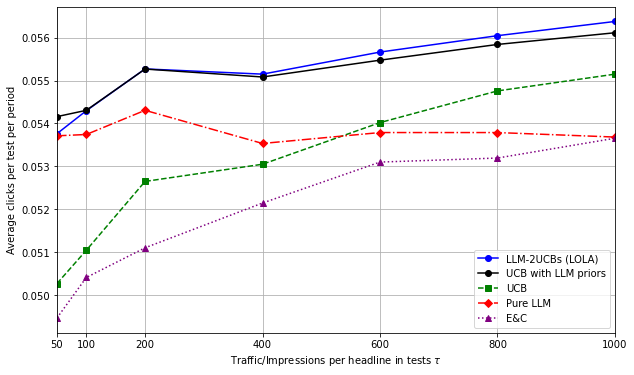

In [2]:
result_simulation_df = pd.read_csv('simulation_results_regret_min.csv')

plt.figure(figsize=(10, 6))
result_simulation_df['T'] = pd.to_numeric(result_simulation_df['T'], errors='coerce')

markers = ['o', 'o','s', 'D', '^']
labels = ['LLM-2UCBs (LOLA)', 'UCB with LLM priors','UCB', 'Pure LLM', 'E&C']
columns = ['ucb2', 'one_ucb','ucb1', 'no_bandit', 'ab']

linestyles = ['-','-', '--', '-.', ':']
colors = ['blue','black', 'green', 'red', 'purple']


for text_, label, marker, linestyle, color in zip(columns, labels, markers, linestyles, colors):
    result_simulation_df[text_+'_result'] = result_simulation_df[text_+'_result'].apply(ast.literal_eval)
    #result_simulation_df[text_+'_result'] = pd.to_numeric(result_simulation_df[text_+'_result'], errors='coerce')

    #result_simulation_df[text_+'_result'] = np.array(result_simulation_df[text_+'_result'])
    result_simulation_df[text_ + '_mean'] = result_simulation_df.apply(
        lambda row: np.mean(np.array([row[text_ + '_result']]) / row['T']), axis=1)

    #result_simulation_df[text_ + '_lb'] = result_simulation_df.apply(
    #    lambda row: compute_confidence_interval(np.array([row[text_ + '_result']]) / row['T'])[0], axis=1)

    #result_simulation_df[text_ + '_ub'] = result_simulation_df.apply(
    #    lambda row: compute_confidence_interval(np.array([row[text_ + '_result']]) / row['T'])[1], axis=1)

    plt.plot(result_simulation_df['T'], result_simulation_df[text_ + '_mean'], marker=marker, linestyle=linestyle, color=color, label=label)


plt.xlabel(r'Traffic/Impressions per headline in tests $\tau$')
plt.ylabel('Average clicks per test per period')
plt.xticks([50, 100, 200, 400, 600, 800, 1000])
#plt.xticks([50, 100, 200])

plt.xlim([50, 1000])
plt.legend()
plt.grid(True)
plt.savefig('2ucb_simulation_compr_2.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [3]:
import itertools
from scipy.stats import ttest_rel


# Map the labels to their respective columns in the dataframe
label_to_column = {
    'LLM-2UCBs (LOLA)': 'ucb2',
    'UCB': 'ucb1',
    'Pure LLM': 'no_bandit',
    'E&C': 'ab',
    'LLM-2UCBs (with only U$^2$)': 'one_ucb'
}
comparisons = list(itertools.combinations(label_to_column.keys(), 2))


# Prepare the result dataframe
comparison_results = pd.DataFrame({
    'T': result_simulation_df['T']
})

# Compute the mean differences and p-values for each comparison
for label1, label2 in comparisons:
    col1 = label_to_column[label1]
    col2 = label_to_column[label2]
    
    mean_diff_col = f'{label1} v.s. {label2}_mean_diff'
    p_value_col = f'{label1} v.s. {label2}_p_value'
    
    mean_diffs = []
    p_values = []
    
    for _, row in result_simulation_df.iterrows():
        data1 = np.array([row[f'{col1}_result']]) / row['T']
        data2 = np.array([row[f'{col2}_result']]) / row['T']
        
        mean_diff = np.mean(data1[0] - data2[0])/np.mean(data2[0])*100
        t_stat, p_value = ttest_rel(data1[0], data2[0])
        
        mean_diffs.append(mean_diff)
        p_values.append(p_value)
    
    comparison_results[mean_diff_col] = mean_diffs
    comparison_results[p_value_col] = p_values

comparison_results

,T,LLM-2UCBs (LOLA) v.s. UCB_mean_diff,LLM-2UCBs (LOLA) v.s. UCB_p_value,LLM-2UCBs (LOLA) v.s. Pure LLM_mean_diff,LLM-2UCBs (LOLA) v.s. Pure LLM_p_value,LLM-2UCBs (LOLA) v.s. E&C_mean_diff,LLM-2UCBs (LOLA) v.s. E&C_p_value,LLM-2UCBs (LOLA) v.s. LLM-2UCBs (with only U$^2$)_mean_diff,LLM-2UCBs (LOLA) v.s. LLM-2UCBs (with only U$^2$)_p_value,UCB v.s. Pure LLM_mean_diff,...,UCB v.s. E&C_mean_diff,UCB v.s. E&C_p_value,UCB v.s. LLM-2UCBs (with only U$^2$)_mean_diff,UCB v.s. LLM-2UCBs (with only U$^2$)_p_value,Pure LLM v.s. E&C_mean_diff,Pure LLM v.s. E&C_p_value,Pure LLM v.s. LLM-2UCBs (with only U$^2$)_mean_diff,Pure LLM v.s. LLM-2UCBs (with only U$^2$)_p_value,E&C v.s. LLM-2UCBs (with only U$^2$)_mean_diff,E&C v.s. LLM-2UCBs (with only U$^2$)_p_value
0,50,6.950372,2.571423e-22,0.091293,8.122596e-01,8.686493,3.943269e-07,-0.735627,0.007583,-6.413329,...,1.623296,3.293771e-01,-7.186510,2.232473e-26,8.587361,6.165060e-07,-0.826166,1.970328e-03,-8.669081,3.244017e-08
1,100,6.376464,4.875645e-28,1.032162,3.174344e-03,7.715224,1.516692e-09,-0.016930,0.948675,-5.023951,...,1.258512,2.976455e-01,-6.010158,3.817042e-26,6.614786,2.809597e-07,-1.038375,4.039958e-06,-7.178330,1.581497e-09
2,200,4.982828,1.736058e-22,1.777652,1.259250e-07,8.162409,1.020894e-16,0.005545,0.980686,-3.053047,...,3.028667,1.093943e-03,-4.741045,1.114529e-21,6.273240,4.285535e-10,-1.741156,6.515587e-12,-7.541311,1.837989e-16
3,400,3.960196,7.431338e-22,3.019851,8.425324e-16,5.764201,1.937489e-15,0.121011,0.556964,-0.904524,...,1.735285,1.307779e-02,-3.692937,3.646373e-20,2.663904,5.788553e-04,-2.813865,1.835823e-22,-5.335633,1.685516e-14
4,600,3.044658,2.126871e-16,3.488913,9.525832e-20,4.830844,7.569767e-14,0.340672,0.097685,0.431129,...,1.733409,4.588179e-03,-2.624092,1.886120e-12,1.296690,6.131674e-02,-3.042105,9.333559e-24,-4.283255,4.416253e-12
5,800,2.352019,4.881437e-11,4.199963,5.115852e-27,5.363869,1.117806e-19,0.366333,0.043804,1.805478,...,2.942638,3.406340e-08,-1.940056,3.509646e-08,1.116993,8.650743e-02,-3.679109,2.596135e-30,-4.743121,3.123405e-17
6,1000,2.227829,5.389959e-11,5.020980,1.867417e-37,5.075568,5.328977e-21,0.469140,0.005028,2.732281,...,2.785679,5.071423e-08,-1.720362,4.117956e-07,0.051978,9.319561e-01,-4.334220,2.330083e-40,-4.383919,4.907211e-17


##  Comparison with Thompson Sampling

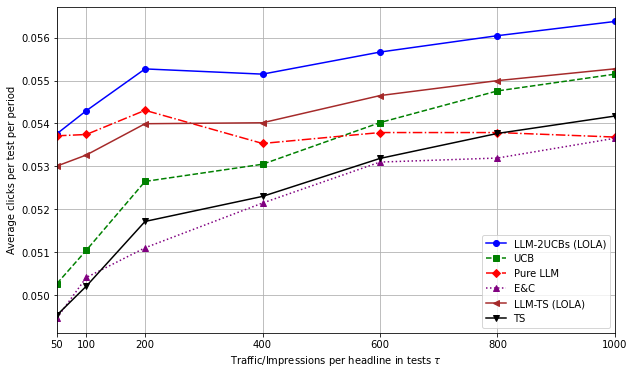

In [4]:
result_simulation_df = pd.read_csv('simulation_results_regret_min.csv')

plt.figure(figsize=(10, 6))
result_simulation_df['T'] = pd.to_numeric(result_simulation_df['T'], errors='coerce')

markers = ['o', 's', 'D', '^', '<', 'v']
labels = ['LLM-2UCBs (LOLA)', 'UCB', 'Pure LLM', 'E&C', 'LLM-TS (LOLA)', 'TS']
columns = ['ucb2', 'ucb1', 'no_bandit', 'ab', 'ts_llm', 'ts']

linestyles = ['-', '--', '-.', ':', '-', '-']
colors = ['blue', 'green', 'red', 'purple', 'brown', 'black']


for text_, label, marker, linestyle, color in zip(columns, labels, markers, linestyles, colors):
    result_simulation_df[text_+'_result'] = result_simulation_df[text_+'_result'].apply(ast.literal_eval)
    #result_simulation_df[text_+'_result'] = pd.to_numeric(result_simulation_df[text_+'_result'], errors='coerce')

    #result_simulation_df[text_+'_result'] = np.array(result_simulation_df[text_+'_result'])
    result_simulation_df[text_ + '_mean'] = result_simulation_df.apply(
        lambda row: np.mean(np.array([row[text_ + '_result']]) / row['T']), axis=1)

    #result_simulation_df[text_ + '_lb'] = result_simulation_df.apply(
    #    lambda row: compute_confidence_interval(np.array([row[text_ + '_result']]) / row['T'])[0], axis=1)

    #result_simulation_df[text_ + '_ub'] = result_simulation_df.apply(
    #    lambda row: compute_confidence_interval(np.array([row[text_ + '_result']]) / row['T'])[1], axis=1)

    plt.plot(result_simulation_df['T'], result_simulation_df[text_ + '_mean'], marker=marker, linestyle=linestyle, color=color, label=label)


plt.xlabel(r'Traffic/Impressions per headline in tests $\tau$')
plt.ylabel('Average clicks per test per period')
plt.xticks([50, 100, 200, 400, 600, 800, 1000])
#plt.xticks([50, 100, 200])
plt.xlim([50, 1000])
plt.legend()
plt.grid(True)
plt.savefig('2ucb_simulation_compr_ts.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [5]:
import itertools
from scipy.stats import ttest_rel


# Map the labels to their respective columns in the dataframe
label_to_column = {
    'LLM-2UCBs': 'ucb2',
    'UCB': 'ucb1',
    'Pure LLM': 'no_bandit',
    'E&C': 'ab',
    'LLM-TS':'ts_llm',
    'TS':'ts'
}
comparisons = list(itertools.combinations(label_to_column.keys(), 2))


# Prepare the result dataframe
comparison_results = pd.DataFrame({
    'T': result_simulation_df['T']
})

# Compute the mean differences and p-values for each comparison
for label1, label2 in comparisons:
    col1 = label_to_column[label1]
    col2 = label_to_column[label2]
    
    mean_diff_col = f'{label1} v.s. {label2}_mean_diff'
    p_value_col = f'{label1} v.s. {label2}_p_value'
    
    mean_diffs = []
    p_values = []
    
    for _, row in result_simulation_df.iterrows():
        data1 = np.array([row[f'{col1}_result']]) / row['T']
        data2 = np.array([row[f'{col2}_result']]) / row['T']
        
        mean_diff = np.mean(data1[0] - data2[0])/np.mean(data2[0])*100
        t_stat, p_value = ttest_rel(data1[0], data2[0])
        
        mean_diffs.append(mean_diff)
        p_values.append(p_value)
    
    comparison_results[mean_diff_col] = mean_diffs
    comparison_results[p_value_col] = p_values



In [6]:
comparison_results

,T,LLM-2UCBs v.s. UCB_mean_diff,LLM-2UCBs v.s. UCB_p_value,LLM-2UCBs v.s. Pure LLM_mean_diff,LLM-2UCBs v.s. Pure LLM_p_value,LLM-2UCBs v.s. E&C_mean_diff,LLM-2UCBs v.s. E&C_p_value,LLM-2UCBs v.s. LLM-TS_mean_diff,LLM-2UCBs v.s. LLM-TS_p_value,LLM-2UCBs v.s. TS_mean_diff,...,Pure LLM v.s. LLM-TS_mean_diff,Pure LLM v.s. LLM-TS_p_value,Pure LLM v.s. TS_mean_diff,Pure LLM v.s. TS_p_value,E&C v.s. LLM-TS_mean_diff,E&C v.s. LLM-TS_p_value,E&C v.s. TS_mean_diff,E&C v.s. TS_p_value,LLM-TS v.s. TS_mean_diff,LLM-TS v.s. TS_p_value
0,50,6.950372,2.571423e-22,0.091293,8.122596e-01,8.686493,3.943269e-07,1.422294,1.436749e-03,8.538547,...,1.329787,1.787521e-03,8.439550,5.544775e-31,-6.683626,2.165559e-05,-0.136122,0.934530,7.016458,3.191127e-27
1,100,6.376464,4.875645e-28,1.032162,3.174344e-03,7.715224,1.516692e-09,1.939010,9.527723e-08,8.149188,...,0.897583,7.746228e-03,7.044317,2.387367e-28,-5.362486,5.522174e-06,0.402881,0.736082,6.092052,3.771578e-30
2,200,4.982828,1.736058e-22,1.777652,1.259250e-07,8.162409,1.020894e-16,2.366897,1.109354e-14,6.877241,...,0.578953,5.352523e-02,5.010519,1.389161e-19,-5.358156,2.525263e-09,-1.188183,0.179429,4.406056,2.359043e-23
3,400,3.960196,7.431338e-22,3.019851,8.425324e-16,5.764201,1.937489e-15,2.099261,2.292423e-14,5.451216,...,-0.893604,4.321301e-03,2.360094,2.297417e-06,-3.465199,4.090600e-07,-0.295927,0.654151,3.283035,1.509653e-19
4,600,3.044658,2.126871e-16,3.488913,9.525832e-20,4.830844,7.569767e-14,1.856196,2.183463e-12,4.662710,...,-1.577673,5.732672e-07,1.134225,1.690881e-02,-2.837569,2.967622e-06,-0.160386,0.788427,2.755369,9.947952e-16
5,800,2.352019,4.881437e-11,4.199963,5.115852e-27,5.363869,1.117806e-19,1.905730,1.836638e-13,4.239311,...,-2.201759,4.624009e-12,0.037762,9.346838e-01,-3.282091,2.271165e-09,-1.067309,0.043515,2.289940,9.176387e-13
6,1000,2.227829,5.389959e-11,5.020980,1.867417e-37,5.075568,5.328977e-21,1.997705,6.264065e-17,4.071553,...,-2.878735,2.254780e-17,-0.904035,5.038053e-02,-2.929190,3.705313e-09,-0.955517,0.048870,2.033231,1.021278e-12


## Sensitivity Analysis of Hyperparameter - Auxiliary Sample Size

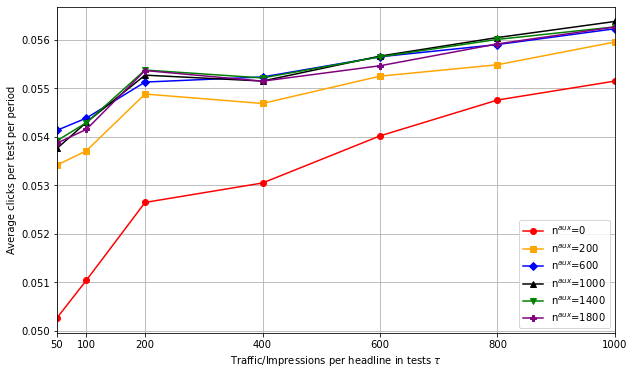

In [7]:
result_simulation_df = pd.read_csv('simulation_results_regret_min.csv')

plt.figure(figsize=(10, 6))
result_simulation_df['T'] = pd.to_numeric(result_simulation_df['T'], errors='coerce')

labels = ['n$^{aux}$=0', 'n$^{aux}$=200', 'n$^{aux}$=600', 'n$^{aux}$=1000', 'n$^{aux}$=1400', 'n$^{aux}$=1800']
columns = ['ucb1', 'ucb2_200', 'ucb2_600', 'ucb2', 'ucb2_1400', 'ucb2_1800']

# Custom plotting options
markers = ['o', 's', 'D', '^', 'v', 'P']  # circle, square, diamond, triangle-up, triangle-down, plus (filled)
linestyles = ['-', '-', '-', '-', '-', '-']  # solid lines
colors = ['red', 'orange', 'blue', 'black', 'green', 'purple']


for text_, label, marker, linestyle, color in zip(columns, labels, markers, linestyles, colors):
    result_simulation_df[text_+'_result'] = result_simulation_df[text_+'_result'].apply(ast.literal_eval)
    #result_simulation_df[text_+'_result'] = pd.to_numeric(result_simulation_df[text_+'_result'], errors='coerce')

    #result_simulation_df[text_+'_result'] = np.array(result_simulation_df[text_+'_result'])
    result_simulation_df[text_ + '_mean'] = result_simulation_df.apply(
        lambda row: np.mean(np.array([row[text_ + '_result']]) / row['T']), axis=1)

    #result_simulation_df[text_ + '_lb'] = result_simulation_df.apply(
    #    lambda row: compute_confidence_interval(np.array([row[text_ + '_result']]) / row['T'])[0], axis=1)

    #result_simulation_df[text_ + '_ub'] = result_simulation_df.apply(
    #    lambda row: compute_confidence_interval(np.array([row[text_ + '_result']]) / row['T'])[1], axis=1)

    plt.plot(result_simulation_df['T'], result_simulation_df[text_ + '_mean'], marker=marker, linestyle=linestyle, color=color, label=label)


plt.xlabel(r'Traffic/Impressions per headline in tests $\tau$')
plt.ylabel('Average clicks per test per period')
plt.xticks([50, 100, 200, 400, 600, 800, 1000])
#plt.xticks([50, 100, 200])

plt.xlim([50, 1000])
plt.legend()
plt.grid(True)
plt.savefig('sensitivity_auxiliary_size.pdf', format='pdf', bbox_inches='tight')
plt.show()

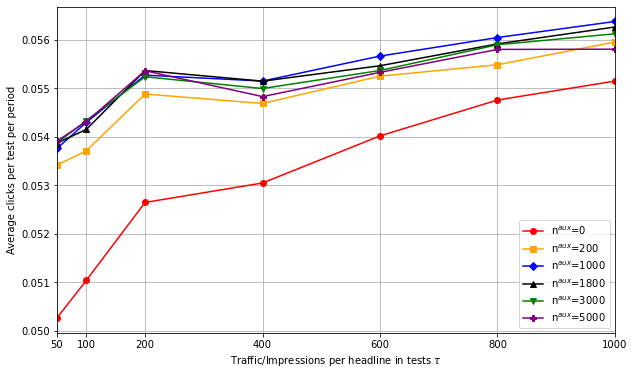

In [8]:
result_simulation_df = pd.read_csv('simulation_results_regret_min.csv')

plt.figure(figsize=(10, 6))
result_simulation_df['T'] = pd.to_numeric(result_simulation_df['T'], errors='coerce')

labels = ['n$^{aux}$=0', 'n$^{aux}$=200', 'n$^{aux}$=1000', 'n$^{aux}$=1800','n$^{aux}$=3000','n$^{aux}$=5000']
columns = ['ucb1', 'ucb2_200', 'ucb2', 'ucb2_1800', 'ucb2_3000', 'ucb2_5000']


markers = ['o', 's', 'D', '^', 'v', 'P']  # circle, square, diamond, triangle-up, triangle-down, plus (filled)
linestyles = ['-', '-', '-', '-', '-', '-']  # solid lines
colors = ['red', 'orange', 'blue', 'black', 'green', 'purple']


for text_, label, marker, linestyle, color in zip(columns, labels, markers, linestyles, colors):
    result_simulation_df[text_+'_result'] = result_simulation_df[text_+'_result'].apply(ast.literal_eval)
    #result_simulation_df[text_+'_result'] = pd.to_numeric(result_simulation_df[text_+'_result'], errors='coerce')

    #result_simulation_df[text_+'_result'] = np.array(result_simulation_df[text_+'_result'])
    result_simulation_df[text_ + '_mean'] = result_simulation_df.apply(
        lambda row: np.mean(np.array([row[text_ + '_result']]) / row['T']), axis=1)

    #result_simulation_df[text_ + '_lb'] = result_simulation_df.apply(
    #    lambda row: compute_confidence_interval(np.array([row[text_ + '_result']]) / row['T'])[0], axis=1)

    #result_simulation_df[text_ + '_ub'] = result_simulation_df.apply(
    #    lambda row: compute_confidence_interval(np.array([row[text_ + '_result']]) / row['T'])[1], axis=1)

    plt.plot(result_simulation_df['T'], result_simulation_df[text_ + '_mean'], marker=marker, linestyle=linestyle, color=color, label=label)


plt.xlabel(r'Traffic/Impressions per headline in tests $\tau$')
plt.ylabel('Average clicks per test per period')
plt.xticks([50, 100, 200, 400, 600, 800, 1000])
#plt.xticks([50, 100, 200])

plt.xlim([50, 1000])
plt.legend()
plt.grid(True)
plt.savefig('sensitivity_auxiliary_size.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Appendix: Run LOLA and Benchmarks on test data

In [ ]:
import pandas as pd
#from openai import OpenAI
import torch
import numpy as np
import os
import matplotlib.pyplot as plt
import time, datetime
from sklearn.metrics.pairwise import cosine_similarity
import scipy.stats as stats
import ast
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import train_test_split
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from concurrent.futures import ThreadPoolExecutor

#revised version 2
def compute_confidence_interval(results):
    # Convert results to a numpy array for statistical calculations, if not already
    results = np.array(results)
    
    # Calculate mean and standard deviation
    mean = np.mean(results)
    std_dev = np.std(results, ddof=1)  # ddof=1 for sample standard deviation
    std_error = std_dev / np.sqrt(len(results))
    z_score = stats.norm.ppf(0.975)  # two-tailed test, so 0.975 instead of 0.95
    margin_of_error = z_score * std_error

    confidence_interval = (mean - margin_of_error, mean + margin_of_error)

    return confidence_interval


def get_UCB(num_trials, num_positive, z_value, t, ctr_llm, n_llm, two_ucb=True):
    
    mean_val = num_positive / num_trials
    ucb = mean_val + z_value * np.sqrt(np.log(t + 2) / num_trials)

    ucb_llm = np.where(n_llm > 0,
                       (ctr_llm * n_llm + num_positive) / (num_trials + n_llm) + z_value * np.sqrt(np.log(t + 2) / (num_trials + n_llm)),
                       ucb)  # Default to ucb if n_llm <= 0
    if two_ucb == True:
        return np.minimum(ucb, ucb_llm)
    else:
        return ucb_llm



def simulate_bandit(df, T, n_value, z_value, ini = 1000, two_ucb=True):
    rng = np.random.RandomState(42)
    
    results = []
    results_ab = []

    sampled_ids = df['test_id'].drop_duplicates().sample(n=n_value, random_state=rng)
    sampled_df = df[df['test_id'].isin(sampled_ids)]
    
    
    for test_id, group in sampled_df.groupby('test_id'):
        # Initialize data structures for arms
        trials = np.ones(len(group))  # Start each arm with one trial initially
        successes = np.zeros(len(group))  # Initial clicks as successes
        ctr_llm = np.array(group['ini_CTR'].values)  # Initial CTR estimates
        #n_llm = np.array(group['initial_trials'].values)  # Initial number of trials
        n_llm = ini*np.ones(len(group))
        total_T = int(len(group)*T)

        
        rewards = np.zeros(total_T)
        
        for t in range(total_T):
            # Calculate UCB for each arm
            ucbs = get_UCB(trials, successes, z_value, t, ctr_llm, n_llm, two_ucb)
            
            # Choose the arm with the highest UCB
            chosen_arm = np.argmax(ucbs)
            ctr = group.iloc[chosen_arm]['CTR']
            
            # Simulate reward using the binomial distribution
            reward = rng.binomial(1, ctr)
            
            # Update trials and successes
            trials[chosen_arm] += 1
            successes[chosen_arm] += reward
            
            # Update cumulative rewards for this simulation
            rewards[t] = reward
        
        # Sum of rewards for this test_id
        results.append(np.sum(rewards))
        
    return results        


def get_Thompson_Sampling(alpha, beta, n_llm, ctr_llm):
    # Sample from the Beta distribution
    samples = np.random.beta(alpha + ctr_llm * n_llm, beta + (1 - ctr_llm) * n_llm)
    return samples

def simulate_thompson_sampling(df, T, n_value, a_ = 1, b_ = 100, ini = 1000):
    # LOLA: LLM+Thompson Sampling if n_value > 0
    # Pure Thompson Sampling: if n_value == 0
    rng = np.random.RandomState(42)
    
    results = []
    
    sampled_ids = df['test_id'].drop_duplicates().sample(n=n_value, random_state=rng)
    sampled_df = df[df['test_id'].isin(sampled_ids)]
    
    for test_id, group in sampled_df.groupby('test_id'):
        # Initialize data structures for arms
        trials = np.ones(len(group))  # Start each arm with one trial initially
        successes = np.zeros(len(group))  # Initial clicks as successes
        alpha = a_*np.ones(len(group))  # Prior alpha (successes)
        beta = b_*np.ones(len(group))   # Prior beta (failures)
        ctr_llm = np.array(group['ini_CTR'].values)  # Initial CTR estimates
        ctr_llm = np.maximum(ctr_llm, 0)
        #n_llm = np.array(group['initial_trials'].values)  # Initial number of trials
        n_llm = ini*np.ones(len(group))
        total_T = int(len(group) * T)
        
        rewards = np.zeros(total_T)
        
        for t in range(total_T):
            # Sample from the Beta distribution for each arm
            ts_samples = get_Thompson_Sampling(alpha, beta, n_llm, ctr_llm)
            
            # Choose the arm with the highest sample value
            chosen_arm = np.argmax(ts_samples)
            ctr = group.iloc[chosen_arm]['CTR']
            
            # Simulate reward using the binomial distribution
            reward = rng.binomial(1, ctr)
            
            # Update trials and successes
            trials[chosen_arm] += 1
            successes[chosen_arm] += reward
            
            # Update alpha and beta parameters
            alpha[chosen_arm] += reward
            beta[chosen_arm] += (1 - reward)
            
            # Update cumulative rewards for this simulation
            rewards[t] = reward
        
        # Sum of rewards for this test_id
        results.append(np.sum(rewards))
        
    return results

def simulate_LLM_no_bandit(df, T, n_value):
    rng = np.random.RandomState(42)
    
    results_no_bandit = []

    sampled_ids = df['test_id'].drop_duplicates().sample(n=n_value, random_state=rng)
    sampled_df = df[df['test_id'].isin(sampled_ids)]
    
    
    for test_id, group in sampled_df.groupby('test_id'):
        total_T = int(len(group)*T)
        rewards_no_bandit = np.zeros(total_T)
        #for t in range(total_T):
        best_arm = np.argmax(group['ini_CTR'])
        ctr = group.iloc[best_arm]['CTR']
        reward = rng.binomial(1, ctr, total_T)
        rewards_no_bandit = reward

        results_no_bandit.append(np.sum(rewards_no_bandit))
        
    return results_no_bandit

def simulate_ab(df, T, n_value, ratio = 0.2):
    #T is the traffic per headline
    rng = np.random.RandomState(42)

    results_ab = []

    sampled_ids = df['test_id'].drop_duplicates().sample(n=n_value, random_state=rng)
    sampled_df = df[df['test_id'].isin(sampled_ids)]
    
    
    for test_id, group in sampled_df.groupby('test_id'):
        total_T = int(len(group)*T)
        
        # Initialize data structures for arms
        trials = np.ones(len(group))  # Start each arm with one trial initially
        successes = np.zeros(len(group))  # Initial clicks as successes
        explore_T = int(ratio * total_T)  # 20% of traffic for exploration/test
        exploit_T = total_T - explore_T  # 80% of traffic for exploitation/roll
        rewards_ab = np.zeros(total_T)
        # Exploration phase
        chosen_arm = rng.choice(len(group), explore_T)
        ctr = group.iloc[chosen_arm]['CTR']
        reward = rng.binomial(1, p = ctr)
        np.add.at(trials, chosen_arm, 1)
        np.add.at(successes, chosen_arm, reward)
        np.add.at(rewards_ab, np.arange(explore_T), reward)
        
        empirical_ctrs = successes / trials
        best_arm = np.argmax(empirical_ctrs)
        ctr = group.iloc[best_arm]['CTR']
        reward = rng.binomial(1, ctr, total_T-explore_T)
        rewards_ab[explore_T:total_T] = reward
        results_ab.append(np.sum(rewards_ab))
    return results_ab
test_df = pd.read_csv('LoRA CTR.csv')

alpha_train = 1.3833788217740643
beta_train = 96.11247058958283

In [ ]:
from concurrent.futures import ProcessPoolExecutor
import os
from multiprocessing import Manager
from threading import Lock
import time


# Setup a manager for multiprocessing that can handle locks
manager = Manager()
lock = manager.Lock()

fixed_n_llm = 1000
fixed_n_llm_ts = 1200
best_z_ucb1 = 0.08
best_z_ucb2 = 0.08
best_ratio = 0.2

def run_simulation(T):
    print('----------------------------------')
    print('Test for T = ', T)
    
    n_test = test_df.groupby('test_id').ngroups
    
    print('test for pure LLM at T = ', T)
    no_bandit_result = simulate_LLM_no_bandit(test_df, T, n_test)
    
    print('test for EC at T = ', T)
    ab_result = simulate_ab(test_df, T, n_test, best_ratio)
    
    print('test for UCBs at T = ', T)
    ucb1_result = simulate_bandit(test_df, T, n_test, best_z_ucb1, ini=0)
    ucb2_result = simulate_bandit(test_df, T, n_test, best_z_ucb2, ini=fixed_n_llm)
    
    print('test for One UCB+LLM T = ', T)
    one_ucb_result = simulate_bandit(test_df, T, n_test, best_z_ucb2, ini=fixed_n_llm, two_ucb=False)

    print('test for TS at T = ', T)
    ts_result = simulate_thompson_sampling(test_df, T, n_test, a_=alpha_train, b_=beta_train, ini=0)
    ts_llm_result = simulate_thompson_sampling(test_df, T, n_test, a_=alpha_train, b_=beta_train, ini=fixed_n_llm_ts)

    ucb1_result = np.array(ucb1_result)
    ucb2_result = np.array(ucb2_result)
    one_ucb_result = np.array(one_ucb_result)
    no_bandit_result = np.array(no_bandit_result)
    ab_result = np.array(ab_result)
    ts_result = np.array(ts_result)
    ts_llm_result = np.array(ts_llm_result)

    result = (T, best_z_ucb1, best_z_ucb2, best_ratio, ab_result, no_bandit_result, ucb1_result, one_ucb_result, ucb2_result, ts_result, ts_llm_result)
    save_results(result)
    print('Finished T = ', T)
    print('----------------------------------')


def save_results(result):
    lock.acquire()
    try:
        file_exists = os.path.exists('simulation_results_regret_min_new.csv')
        with open('simulation_results_regret_min_new.csv', 'a') as f:
            result_simulation_df = pd.DataFrame([result], columns=[
                'T', 'z_ucb1', 'z_ucb2', 'best_ratio', 'ab_result', 'no_bandit_result',
                'ucb1_result', 'one_ucb_result', 'ucb2_result', 'ts_result', 'ts_llm_result'
            ])
            result_simulation_df.to_csv(f, header=not file_exists, index=False)
    except Exception as e:
        print(f"Failed to write results: {e}")
    finally:
        lock.release()



In [ ]:
# for parallel computing
def main():
    T_list = [50, 100, 200, 400, 600, 800, 1000]
    with ProcessPoolExecutor(max_workers = 3) as executor:
        executor.map(run_simulation, T_list)

main()

In [ ]:
# for non-parallel computing
T_list = [50, 100, 200, 400, 600, 800, 1000]
for t in T_list:
    run_simulation(t)

# Appendix: Sensitivity Analysis on n^aux

In [ ]:
from concurrent.futures import ProcessPoolExecutor
import os
from multiprocessing import Manager
from threading import Lock
import time


# Setup a manager for multiprocessing that can handle locks
manager = Manager()
lock = manager.Lock()

fixed_n_llm = 1000

def run_simulation_sensitivity(T, fixed_n_llm_sensitivity = 1000):

    print('----------------------------------')
    print('Calibration procedure for T = ', T)
    z_values_range = [0.08]
    best_z_ucb1 = z_values_range[0]
    best_z_ucb2 = z_values_range[0]

    ratio_range = [0.2]
    best_ratio = ratio_range[0]
    best_r_ratio = -1
    
    n_test = test_df.groupby('test_id').ngroups
    
   
    print('test for 2UCBs T = ', T)
    ucb2_result = simulate_bandit(test_df, T, n_test, best_z_ucb2, ini=fixed_n_llm_sensitivity)
    ucb2_result = np.array(ucb2_result).tolist()

    result = (T, best_z_ucb2, fixed_n_llm_sensitivity, ucb2_result)
    save_results_sensitivity(result)
    print('Finished T = ', T)
    print('----------------------------------')


def save_results_sensitivity(result):
    lock.acquire()
    try:
        file_exists = os.path.exists('ucb2_sensitivity.csv')
        with open('ucb2_sensitivity.csv', 'a') as f:
            result_simulation_df = pd.DataFrame([result], columns=[
                'T', 'z_ucb2', 'fixed_n_llm', 'ucb2_result'])
            result_simulation_df.to_csv(f, header=not file_exists, index=False)
    except Exception as e:
        print(f"Failed to write results: {e}")
    finally:
        lock.release()


In [ ]:
for t in [50, 100, 200, 400, 600, 800, 1000]:
    run_simulation_sensitivity(t, 0)
    run_simulation_sensitivity(t, 200)
    run_simulation_sensitivity(t, 1000)
    run_simulation_sensitivity(t, 1800)
    run_simulation_sensitivity(t, 3000)
    run_simulation_sensitivity(t, 5000)